# Butterworth Low Pass Filter (BLPF) — Step by Step
> Demonstrates frequency domain filtering using Butterworth filter in Python
>
> **Key difference from Ideal LPF:** Butterworth uses a *smooth* roll-off instead of a hard cutoff — no ringing (Gibbs) artifacts!

In [1]:
%pip install numpy matplotlib opencv-python Pillow -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['text.color']       = '#e6edf3'
plt.rcParams['axes.labelcolor']  = '#8b949e'
plt.rcParams['xtick.color']      = '#484f58'
plt.rcParams['ytick.color']      = '#484f58'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['grid.color']       = '#21262d'

print('✅ Libraries loaded')

✅ Libraries loaded


## Step 1 — Load & Display the Original Image

Image size: 224 × 280 px


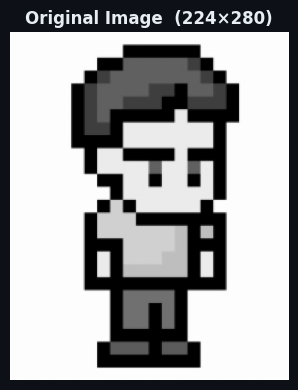

In [3]:
IMAGE_PATH = 'image.png'   # <-- change path if needed

img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float32)
H, W = img.shape
print(f'Image size: {W} × {H} px')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, cmap='gray')
ax.set_title(f'Original Image  ({W}×{H})', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2 — Compute 2D DFT & Shift Zero-Frequency to Center

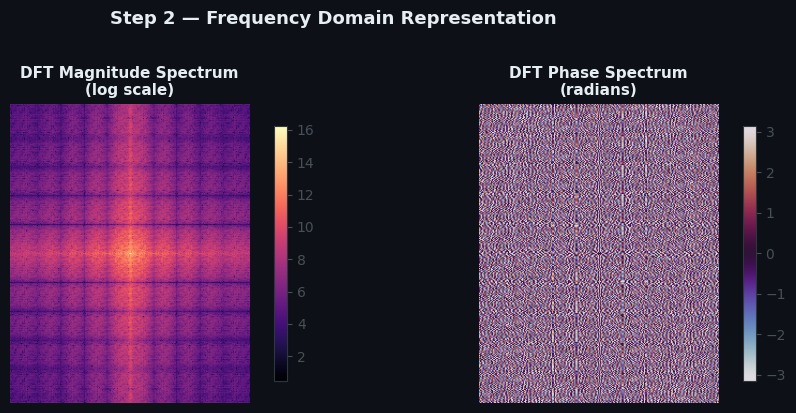

💡 Bright center = low frequencies (smooth regions)
💡 Bright edges  = high frequencies (sharp edges, fine detail)


In [4]:
dft       = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

magnitude = np.abs(dft_shift)
log_mag   = np.log1p(magnitude)
phase     = np.angle(dft_shift)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(log_mag, cmap='magma')
axes[0].set_title('DFT Magnitude Spectrum\n(log scale)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('low ← frequency → high')
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(phase, cmap='twilight')
axes[1].set_title('DFT Phase Spectrum\n(radians)', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.85)

for ax in axes: ax.axis('off')

plt.suptitle('Step 2 — Frequency Domain Representation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Bright center = low frequencies (smooth regions)')
print('💡 Bright edges  = high frequencies (sharp edges, fine detail)')

## Step 3 — Butterworth LPF Formula & Mask

The Butterworth filter uses this transfer function:

$$H(u,v) = \frac{1}{1 + \left(\frac{D(u,v)}{D_0}\right)^{2n}}$$

- **D(u,v)** = distance from center (DC) to point (u,v) in frequency domain  
- **D₀** = cutoff frequency (radius)  
- **n** = order of the filter (higher = steeper roll-off, closer to Ideal LPF)

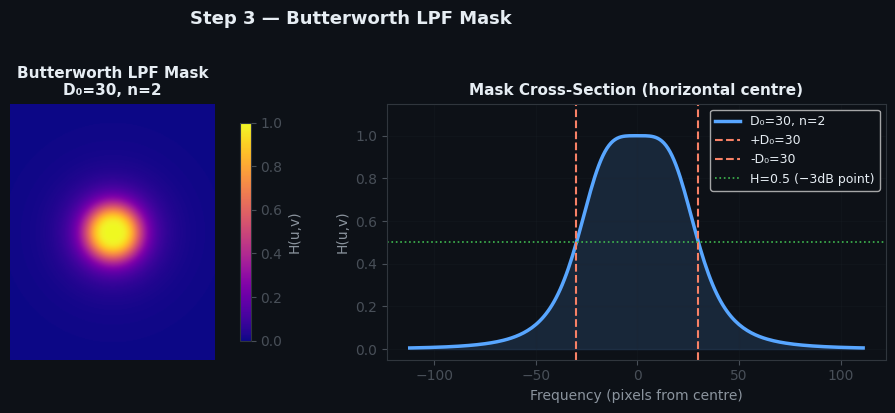

💡 Smooth gradient (no hard cutoff) = no ringing artifacts!
💡 At D=D₀=30, H = 0.5 (the −3dB / half-power point)


In [23]:
def butterworth_lpf_mask(shape, D0, n):
    """
    Butterworth LPF mask.
    H(u,v) = 1 / (1 + (D/D0)^(2n))
    Values range 0.0 → 1.0 (smooth gradient, no hard cutoff)
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    D    = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    H    = 1 / (1 + (D / D0) ** (2 * n))
    return H.astype(np.float32)

# Demo: D0=30, n=2
D0, n = 30, 2
mask  = butterworth_lpf_mask(img.shape, D0, n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 2D mask
im0 = axes[0].imshow(mask, cmap='plasma', vmin=0, vmax=1)
axes[0].set_title(f'Butterworth LPF Mask\nD₀={D0}, n={n}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Bright center = high transmission (pass)')
plt.colorbar(im0, ax=axes[0], shrink=0.85, label='H(u,v)')
axes[0].axis('off')

# 1D cross-section
mid = mask[mask.shape[0] // 2, :]
xs  = np.arange(mask.shape[1]) - mask.shape[1] // 2
axes[1].plot(xs, mid, color='#58a6ff', linewidth=2.5, label=f'D₀={D0}, n={n}')
axes[1].axvline( D0, color='#f78166', linestyle='--', linewidth=1.5, label=f'+D₀={D0}')
axes[1].axvline(-D0, color='#f78166', linestyle='--', linewidth=1.5, label=f'-D₀={D0}')
axes[1].axhline(0.5, color='#3fb950', linestyle=':', linewidth=1.2, label='H=0.5 (−3dB point)')
axes[1].fill_between(xs, mid, alpha=0.15, color='#58a6ff')
axes[1].set_title('Mask Cross-Section (horizontal centre)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Frequency (pixels from centre)')
axes[1].set_ylabel('H(u,v)')
axes[1].set_ylim(-0.05, 1.15)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle('Step 3 — Butterworth LPF Mask', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Smooth gradient (no hard cutoff) = no ringing artifacts!')
print(f'💡 At D=D₀={D0}, H = 0.5 (the −3dB / half-power point)')

## Step 4 — Effect of Order `n` on the Mask Shape

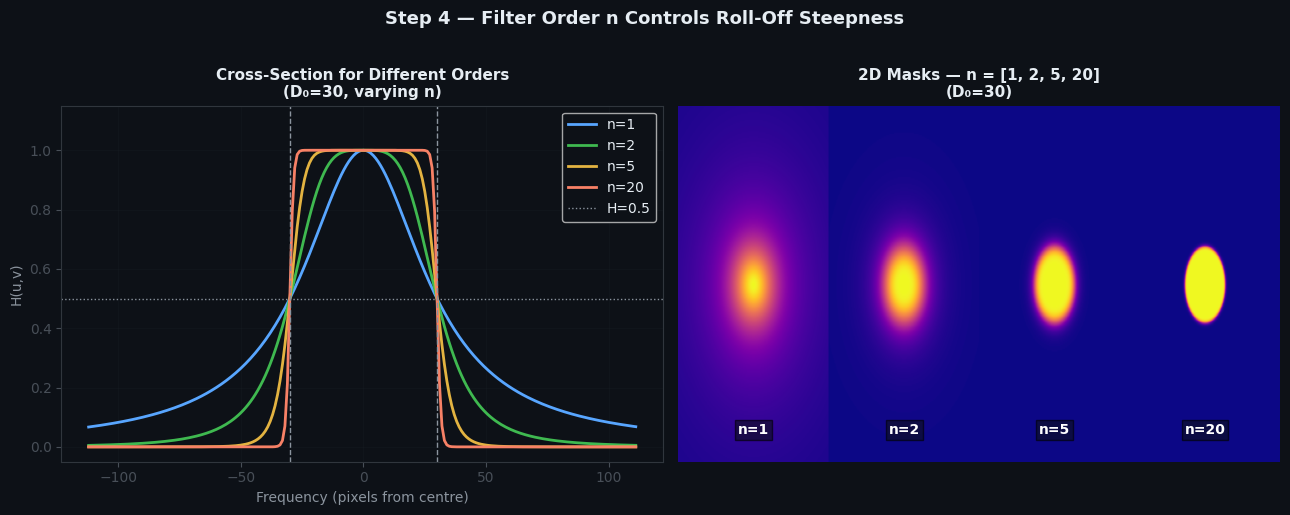

💡 n=1  → very gradual roll-off (most smooth)
💡 n=20 → approaches Ideal LPF hard cutoff (ringing reappears!)


In [6]:
ORDERS = [1, 2, 5, 20]
D0_fixed = 30

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#58a6ff', '#3fb950', '#e3b341', '#f78166']

for order, color in zip(ORDERS, colors):
    m   = butterworth_lpf_mask(img.shape, D0_fixed, order)
    mid = m[H // 2, :]
    xs  = np.arange(W) - W // 2
    axes[0].plot(xs, mid, color=color, linewidth=2, label=f'n={order}')

axes[0].axvline( D0_fixed, color='#8b949e', linestyle='--', linewidth=1)
axes[0].axvline(-D0_fixed, color='#8b949e', linestyle='--', linewidth=1)
axes[0].axhline(0.5, color='#8b949e', linestyle=':', linewidth=1, label='H=0.5')
axes[0].set_title(f'Cross-Section for Different Orders\n(D₀={D0_fixed}, varying n)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Frequency (pixels from centre)')
axes[0].set_ylabel('H(u,v)')
axes[0].set_ylim(-0.05, 1.15)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.2)

# 2D masks side by side as grid
combined = np.hstack([
    butterworth_lpf_mask(img.shape, D0_fixed, o) for o in ORDERS
])
axes[1].imshow(combined, cmap='plasma', vmin=0, vmax=1, aspect='auto')
axes[1].set_title(f'2D Masks — n = {ORDERS}\n(D₀={D0_fixed})', fontsize=11, fontweight='bold')
for i, o in enumerate(ORDERS):
    cx = int((i + 0.5) * W)
    axes[1].text(cx, H * 0.92, f'n={o}', ha='center', fontsize=10,
                 color='white', fontweight='bold',
                 bbox=dict(facecolor='#0d1117', alpha=0.6, pad=2))
axes[1].axis('off')

plt.suptitle('Step 4 — Filter Order n Controls Roll-Off Steepness', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 n=1  → very gradual roll-off (most smooth)')
print('💡 n=20 → approaches Ideal LPF hard cutoff (ringing reappears!)')

## Step 5 — Apply Mask & View Filtered Spectrum

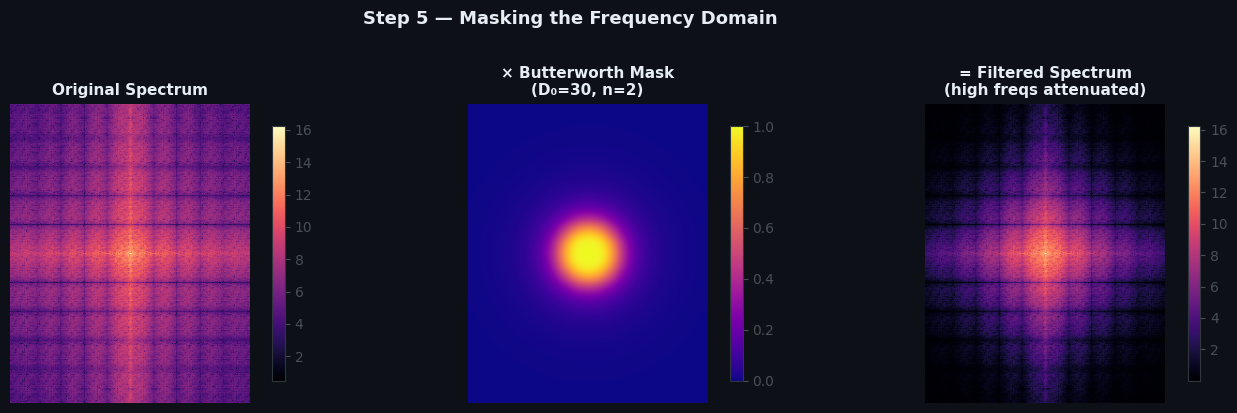

In [7]:
D0, n = 30, 2
mask          = butterworth_lpf_mask(img.shape, D0, n)
filtered_shift = dft_shift * mask
filtered_log   = np.log1p(np.abs(filtered_shift))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(log_mag, cmap='magma')
axes[0].set_title('Original Spectrum', fontsize=11, fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(mask, cmap='plasma', vmin=0, vmax=1)
axes[1].set_title(f'× Butterworth Mask\n(D₀={D0}, n={n})', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(filtered_log, cmap='magma')
axes[2].set_title('= Filtered Spectrum\n(high freqs attenuated)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes: ax.axis('off')

plt.suptitle('Step 5 — Masking the Frequency Domain', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 6 — Inverse DFT → Filtered Image

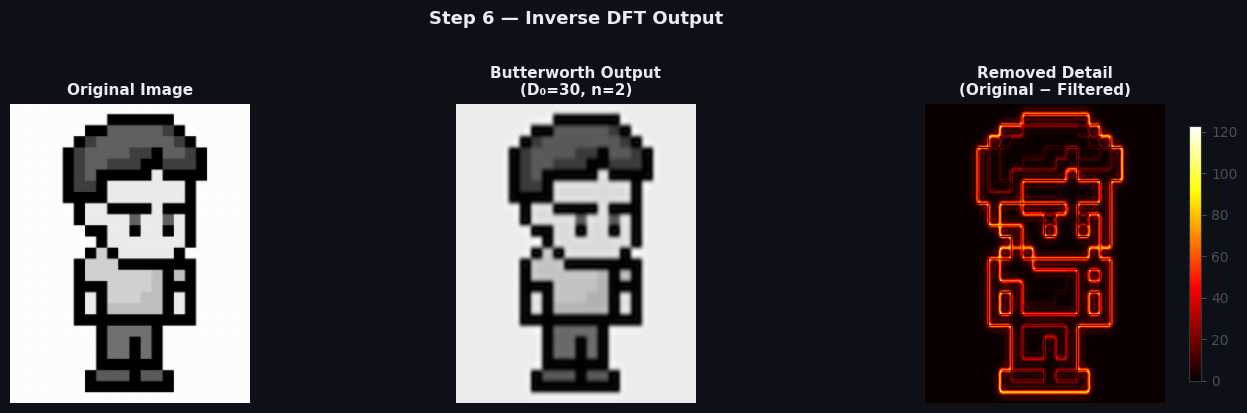

💡 Smooth blurring with no ringing — Butterworth advantage over Ideal LPF!


In [8]:
filtered_img = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered_shift)))
diff         = np.abs(img - filtered_img)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img,          cmap='gray');  axes[0].set_title('Original Image',            fontsize=11, fontweight='bold')
axes[1].imshow(filtered_img, cmap='gray');  axes[1].set_title(f'Butterworth Output\n(D₀={D0}, n={n})', fontsize=11, fontweight='bold')
im2 = axes[2].imshow(diff,   cmap='hot');   axes[2].set_title('Removed Detail\n(Original − Filtered)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes: ax.axis('off')

plt.suptitle('Step 6 — Inverse DFT Output', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Smooth blurring with no ringing — Butterworth advantage over Ideal LPF!')

## Step 7 — Compare Multiple Cutoff Radii (D₀) at Fixed Order

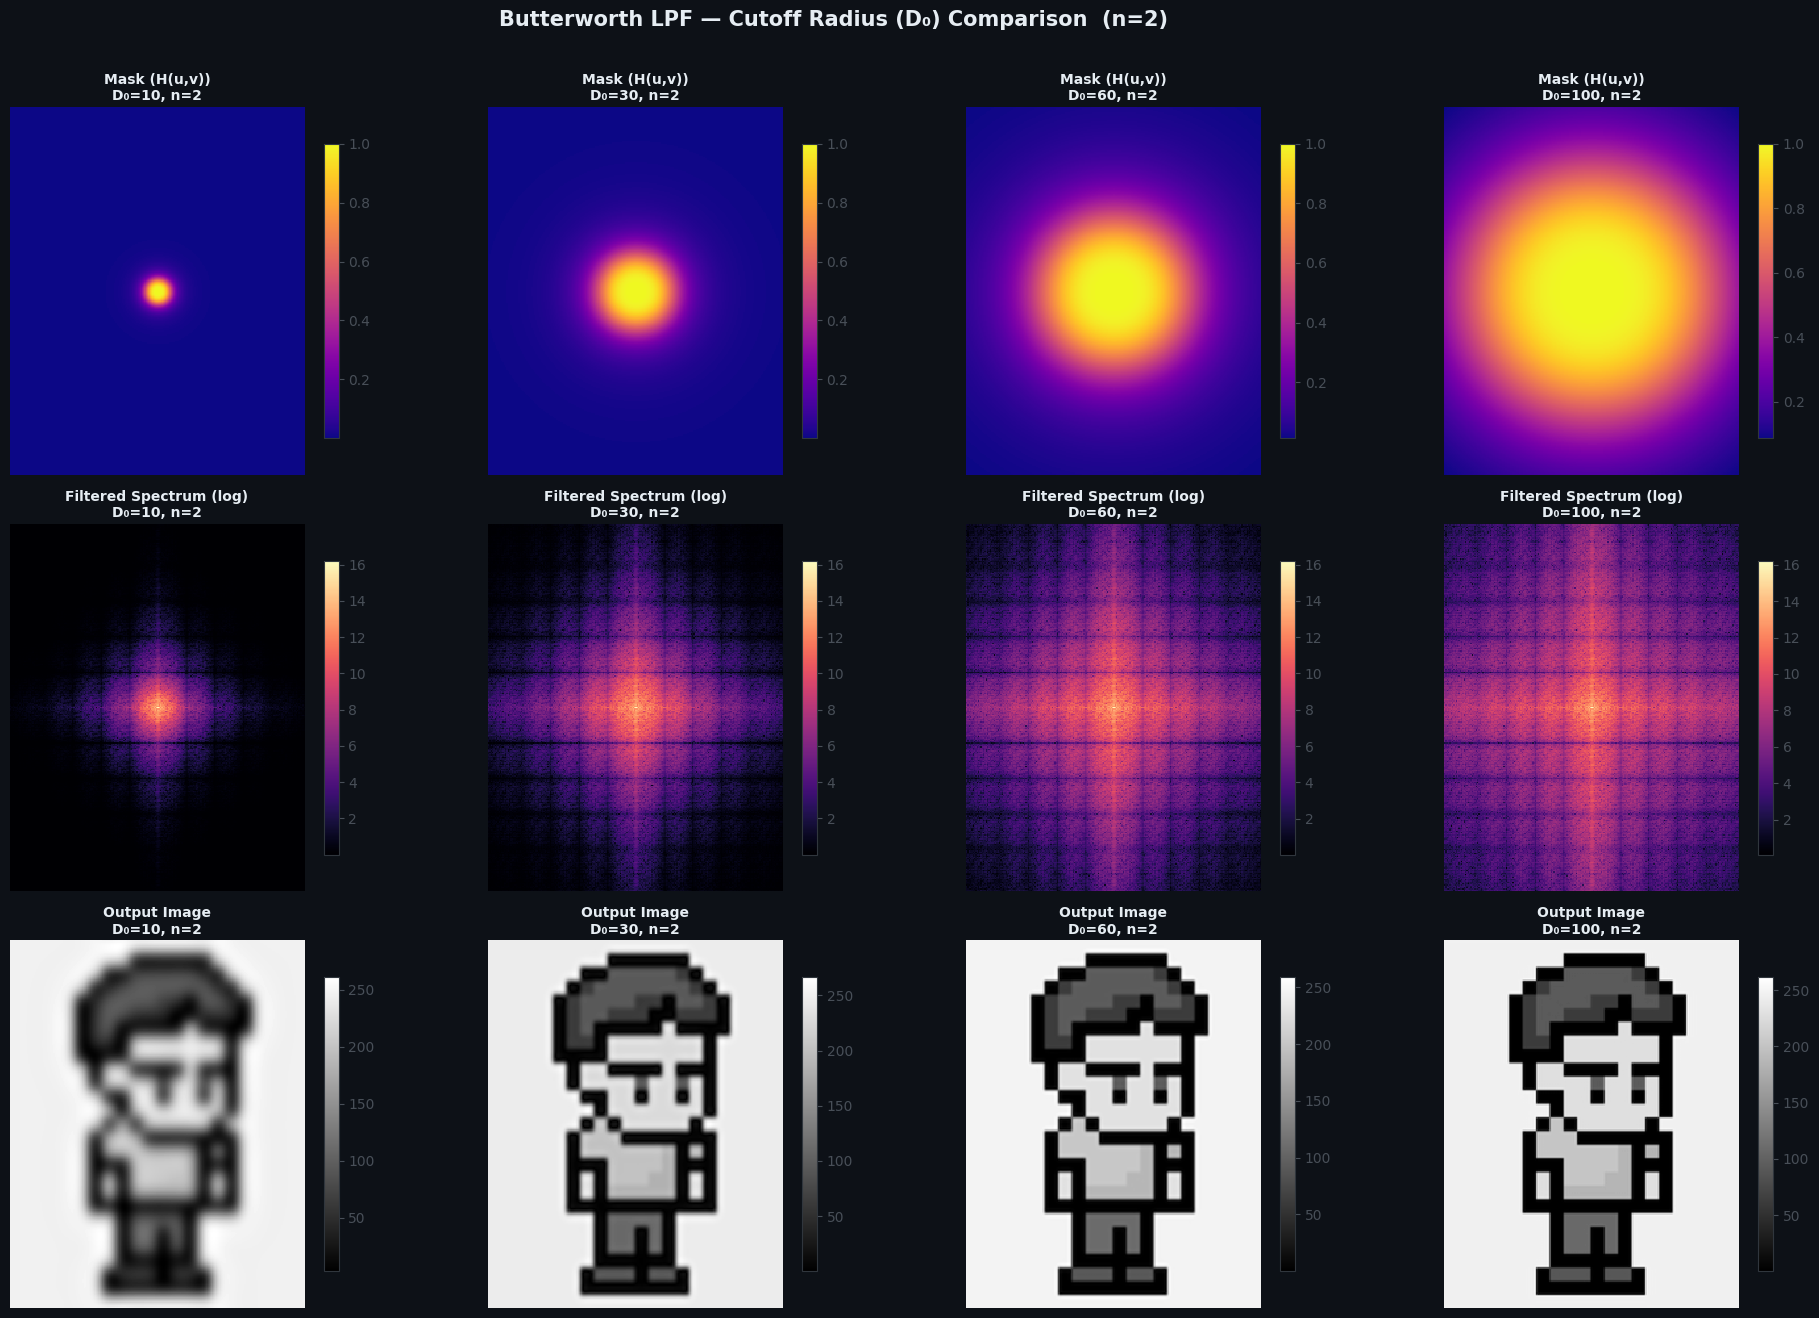

In [9]:
CUTOFF_RADII = [10, 30, 60, 100]
N_FIXED      = 2

fig, axes = plt.subplots(3, len(CUTOFF_RADII), figsize=(5 * len(CUTOFF_RADII), 13))
row_labels = ['Mask (H(u,v))', 'Filtered Spectrum (log)', 'Output Image']
cmaps      = ['plasma', 'magma', 'gray']

for col, D0_val in enumerate(CUTOFF_RADII):
    m  = butterworth_lpf_mask(img.shape, D0_val, N_FIXED)
    fs = dft_shift * m
    fi = np.abs(np.fft.ifft2(np.fft.ifftshift(fs)))

    for row, (data, cmap) in enumerate(zip([m, np.log1p(np.abs(fs)), fi], cmaps)):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, interpolation='nearest')
        ax.set_title(f'{row_labels[row]}\nD₀={D0_val}, n={N_FIXED}', fontsize=10, fontweight='bold', pad=5)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)

plt.suptitle(f'Butterworth LPF — Cutoff Radius (D₀) Comparison  (n={N_FIXED})',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — Compare Multiple Orders (n) at Fixed D₀

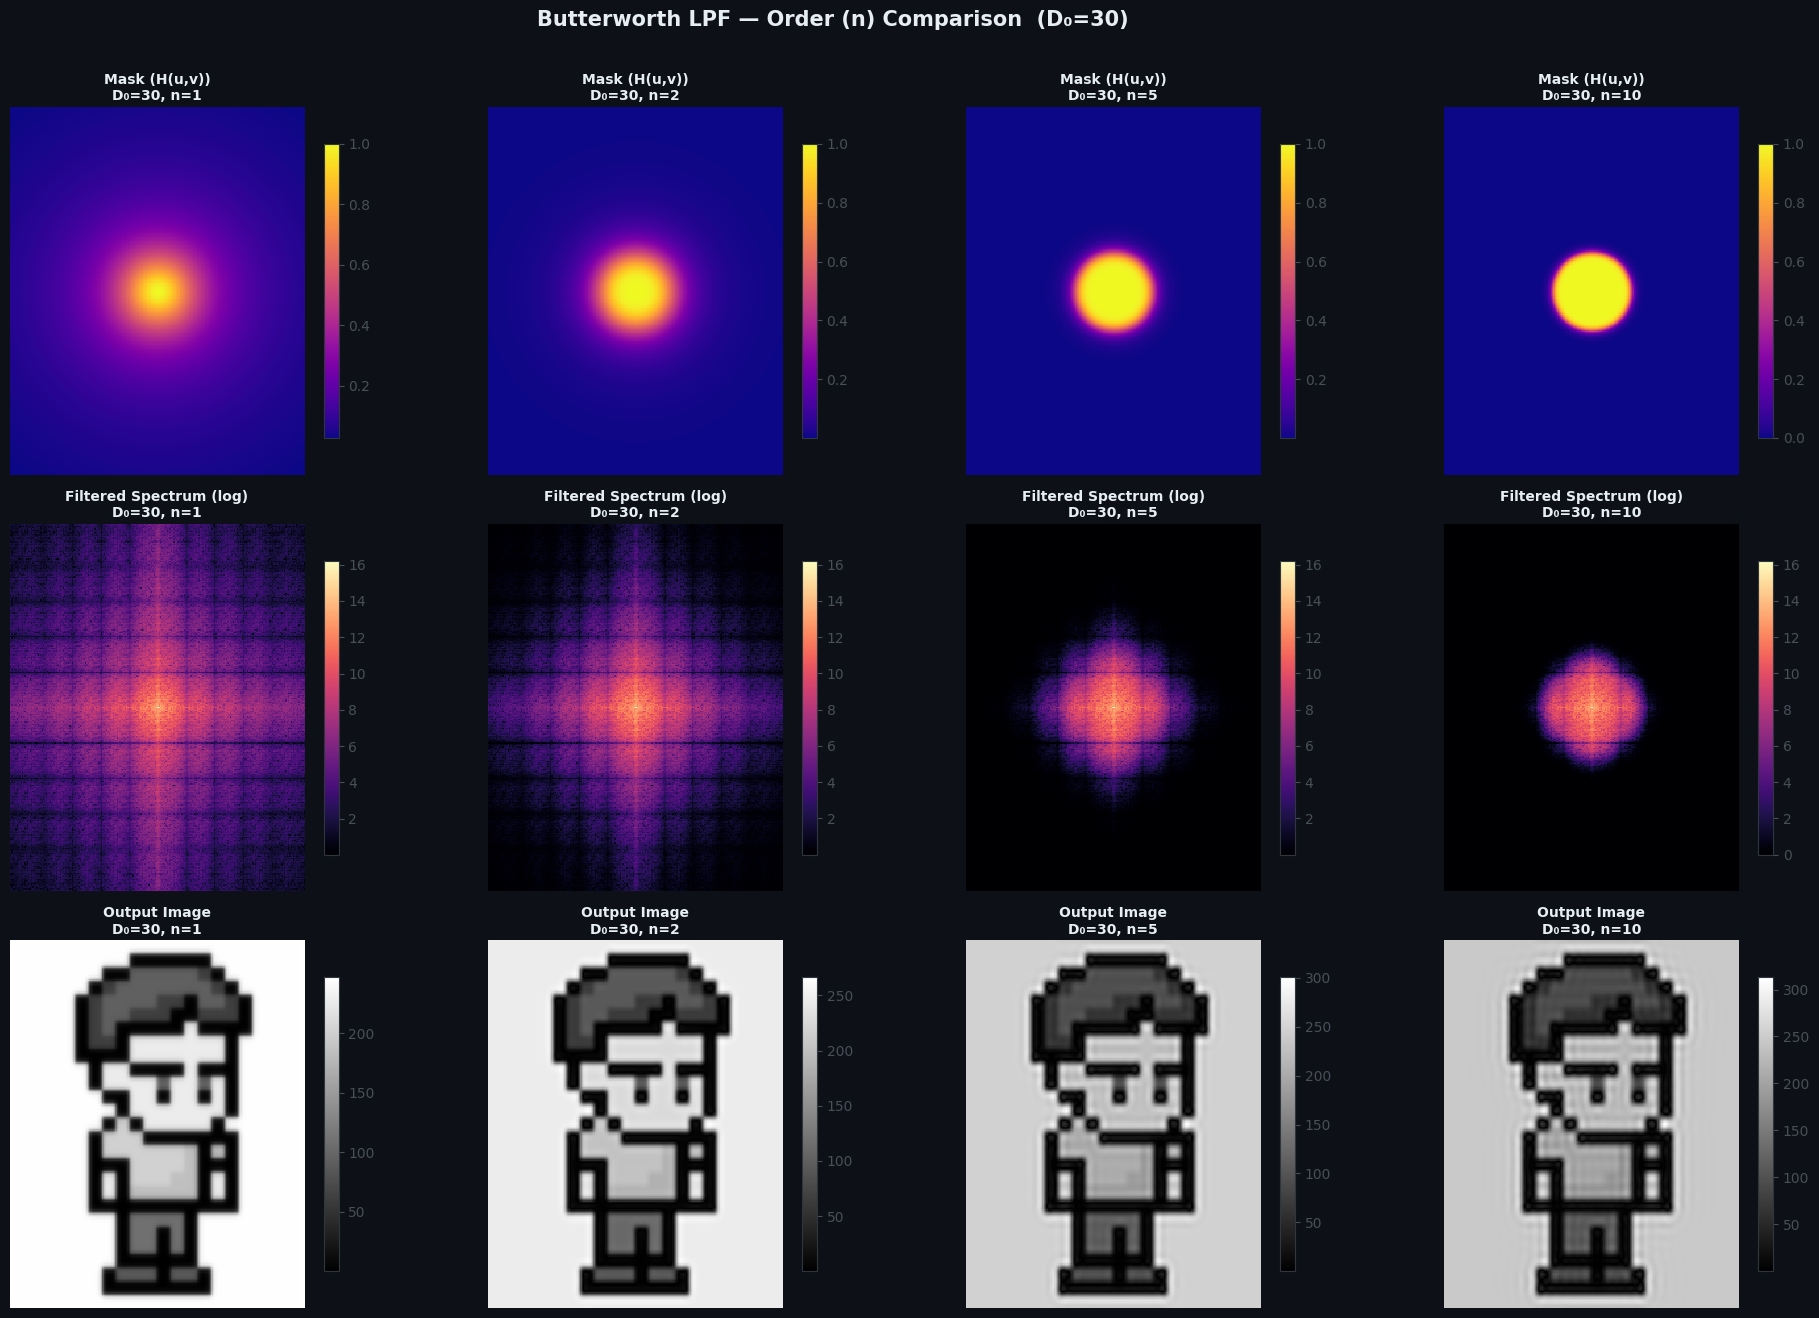

💡 Higher n = steeper cutoff = approaches Ideal LPF behavior (ringing returns!)


In [10]:
ORDERS_LIST = [1, 2, 5, 10]
D0_FIXED    = 30

fig, axes = plt.subplots(3, len(ORDERS_LIST), figsize=(5 * len(ORDERS_LIST), 13))
row_labels = ['Mask (H(u,v))', 'Filtered Spectrum (log)', 'Output Image']
cmaps      = ['plasma', 'magma', 'gray']

for col, order in enumerate(ORDERS_LIST):
    m  = butterworth_lpf_mask(img.shape, D0_FIXED, order)
    fs = dft_shift * m
    fi = np.abs(np.fft.ifft2(np.fft.ifftshift(fs)))

    for row, (data, cmap) in enumerate(zip([m, np.log1p(np.abs(fs)), fi], cmaps)):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, interpolation='nearest')
        ax.set_title(f'{row_labels[row]}\nD₀={D0_FIXED}, n={order}', fontsize=10, fontweight='bold', pad=5)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)

plt.suptitle(f'Butterworth LPF — Order (n) Comparison  (D₀={D0_FIXED})',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Higher n = steeper cutoff = approaches Ideal LPF behavior (ringing returns!)')

## Step 9 — Butterworth vs Ideal LPF: Side-by-Side Comparison

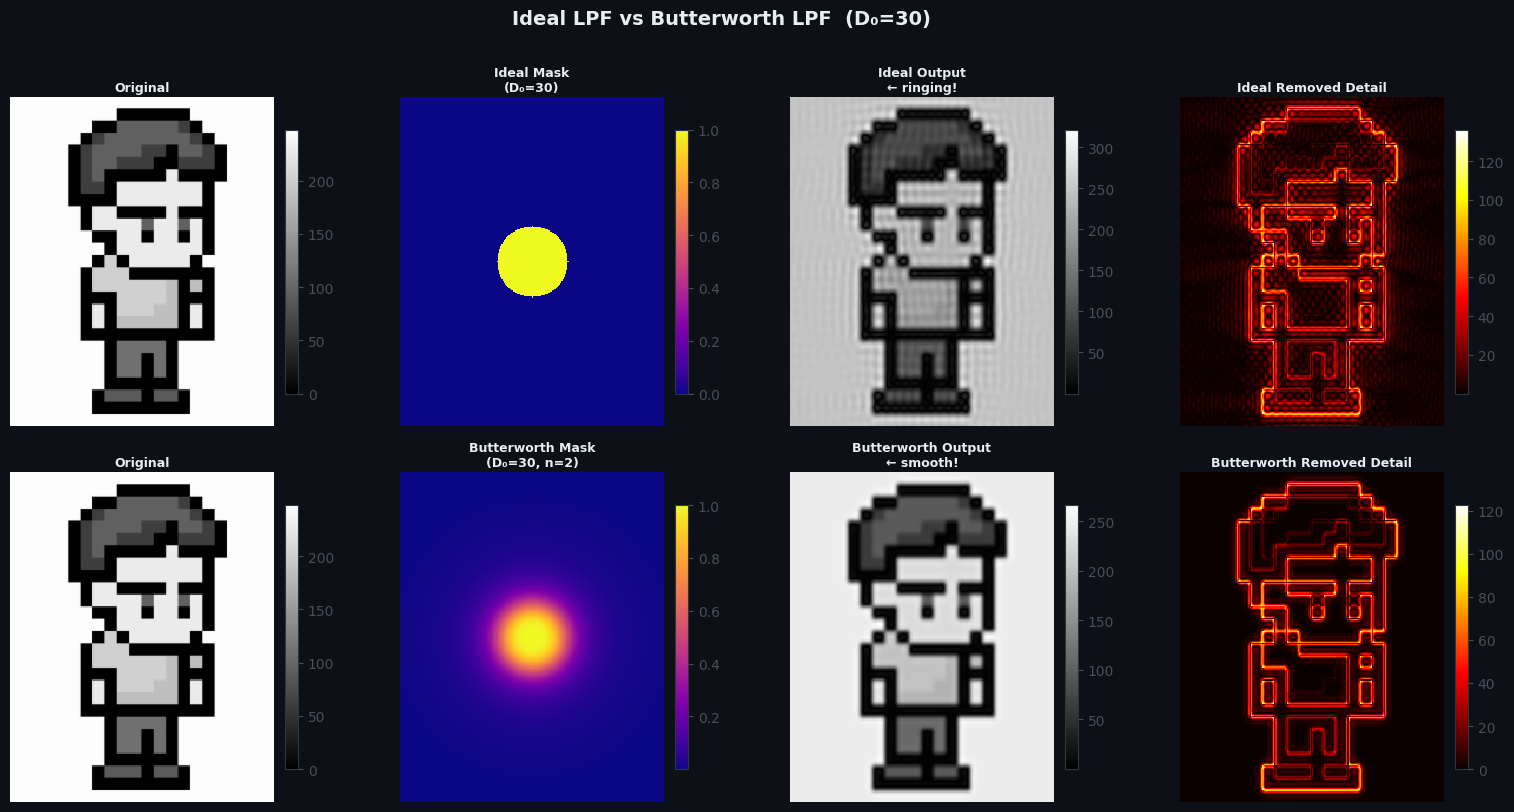

🔴 Ideal LPF    → hard cutoff → ringing/Gibbs artifacts visible
🟢 Butterworth  → smooth roll-off → clean blur, no ringing


In [11]:
def ideal_lpf_mask(shape, D0):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    return (dist <= D0).astype(np.float32)

D0_cmp = 30

ideal_mask  = ideal_lpf_mask(img.shape, D0_cmp)
butter_mask = butterworth_lpf_mask(img.shape, D0_cmp, n=2)

ideal_out   = np.abs(np.fft.ifft2(np.fft.ifftshift(dft_shift * ideal_mask)))
butter_out  = np.abs(np.fft.ifft2(np.fft.ifftshift(dft_shift * butter_mask)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

data_rows = [
    [img,          ideal_mask,  ideal_out,  np.abs(img - ideal_out)],
    [img,          butter_mask, butter_out, np.abs(img - butter_out)],
]
titles_row0 = ['Original',  f'Ideal Mask\n(D₀={D0_cmp})',      'Ideal Output\n← ringing!',         'Ideal Removed Detail']
titles_row1 = ['Original',  f'Butterworth Mask\n(D₀={D0_cmp}, n=2)', 'Butterworth Output\n← smooth!', 'Butterworth Removed Detail']
cmaps_list  = ['gray', 'plasma', 'gray', 'hot']

for col in range(4):
    for row, (data_row, titles) in enumerate(zip(data_rows, [titles_row0, titles_row1])):
        ax = axes[row, col]
        im = ax.imshow(data_row[col], cmap=cmaps_list[col], interpolation='nearest')
        ax.set_title(titles[col], fontsize=9, fontweight='bold', pad=4)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03, shrink=0.8)

# Row labels
axes[0, 0].set_ylabel('IDEAL LPF', fontsize=11, fontweight='bold', color='#f78166', labelpad=10)
axes[1, 0].set_ylabel('BUTTERWORTH LPF', fontsize=11, fontweight='bold', color='#3fb950', labelpad=10)
for ax in axes[:, 0]: ax.yaxis.set_visible(True)

plt.suptitle(f'Ideal LPF vs Butterworth LPF  (D₀={D0_cmp})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('🔴 Ideal LPF    → hard cutoff → ringing/Gibbs artifacts visible')
print('🟢 Butterworth  → smooth roll-off → clean blur, no ringing')

## Step 10 — Interactive: Try Your Own D₀ and n

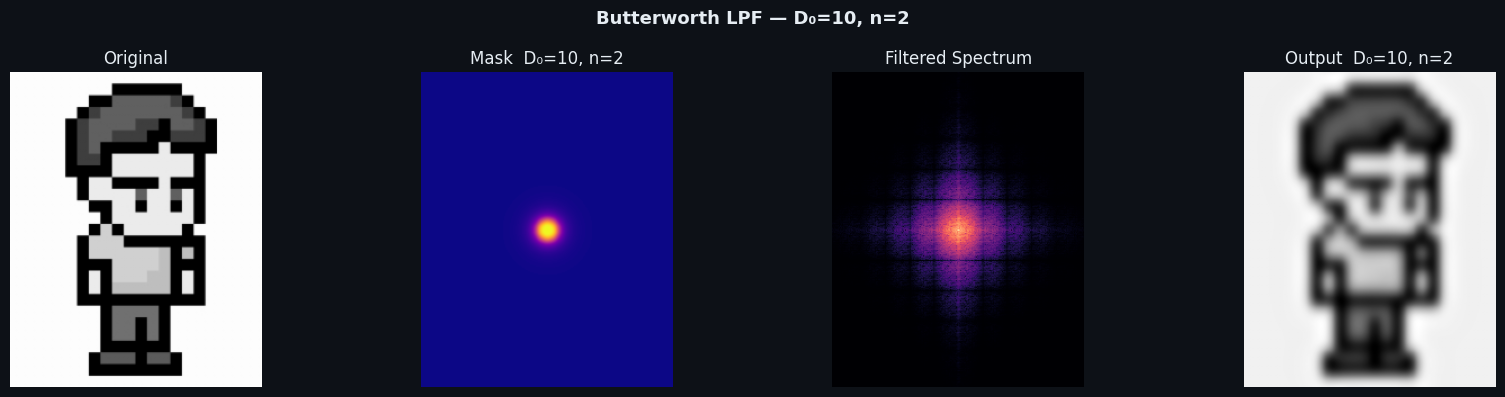

In [21]:
# ── Change these values and re-run ──────────────────────────
D0_custom = 10    # cutoff radius  (try: 5, 15, 40, 80, 120)
n_custom  = 2     # filter order   (try: 1, 2, 5, 10, 20)
# ─────────────────────────────────────────────────────────────

m_c  = butterworth_lpf_mask(img.shape, D0_custom, n_custom)
fs_c = dft_shift * m_c
fi_c = np.abs(np.fft.ifft2(np.fft.ifftshift(fs_c)))

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

axes[0].imshow(img,                     cmap='gray');   axes[0].set_title('Original')
axes[1].imshow(m_c,                     cmap='plasma'); axes[1].set_title(f'Mask  D₀={D0_custom}, n={n_custom}')
axes[2].imshow(np.log1p(np.abs(fs_c)), cmap='magma');  axes[2].set_title('Filtered Spectrum')
axes[3].imshow(fi_c,                    cmap='gray');   axes[3].set_title(f'Output  D₀={D0_custom}, n={n_custom}')

for ax in axes: ax.axis('off')
plt.suptitle(f'Butterworth LPF — D₀={D0_custom}, n={n_custom}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()